# **Second Mini-Project**

## **Massive Graph Management and Analytics**

---


#### **Authors:** Benjamin Gold & Dilbar Isakova
#### **Professor:** Nacera Seghuoani

#### **Outline:**

Exercise 1: Normalized Laplacian Properties

- Symmetric Normalized Laplacian.
- Random Walk Laplacian.

Exercise 2: Different laplacian eigenmaps compared with different clusterings

- Build matrices using the 3 laplacian eigenmaps from the Exercise 1.
- Compare clusterings using matrix like density and normalized cut.


Exercise 4: Compare the different clusterings using node2vec embeddings
- All about Node2Vec
- Node2Vec: Used Clustering Methods
- What is the Silhouette Score?
- Interesting notes on Clustering Methods Results
- Breaking Down Biased Random Walks in Node2Vec: Impact of (p, q) on Node2Vec Embeddings and Clustering
-

Exercise 5: GNNs
- All about GNNs
- What is PyTorch Geometric (PyG)?
- Experiments with Planetoid dataset (Cora)
- All about HITS, MRR, and AUC in GNNs & Link Prediction
- Experiments with Facebook dataset (Page-page)
- Comparison of datasets

# Exercise 1 Properties of the Normalized Laplacians

Are they positive semi-definite?

## Symmetric Normalized Laplacian

The symmetric normalized Laplacian matrix is defined as:

$$
L_{\text{sym}} = D^{-\frac{1}{2}} L D^{-\frac{1}{2}},
$$

where $L = D - A$ is the standard Laplacian matrix of the graph, $A$ is the adjacency matrix, and $D$ is the degree matrix.

### 1. Symmetry
Since both $L$ and $D$ are symmetric, and $D^{-\frac{1}{2}}$ is also symmetric, it follows that $L_{\text{sym}}$ is symmetric:

$$
L_{\text{sym}}^T = L_{\text{sym}}.
$$

### 2. Eigenvalues
The eigenvalues of the symmetric normalized Laplacian $L_{\text{sym}}$ lie in the range $[0, 2]$, and the following properties hold:
- The smallest eigenvalue is $0$, corresponding to the eigenvector $\mathbf{1}$ (the all-ones vector).
- The second smallest eigenvalue, known as the *algebraic connectivity*, gives insights into the graph's connectivity. A larger value indicates better connectivity, while a smaller value suggests weaker connectivity.
- The largest eigenvalue is $2$.

If $\lambda$ is an eigenvalue of the standard Laplacian $L$ with eigenvector $v$, then the eigenvalue of $L_{\text{sym}}$ corresponding to $v$ is scaled, and we have:

$$
L_{\text{sym}} v = D^{-\frac{1}{2}} L D^{-\frac{1}{2}} v = \lambda_{\text{sym}} v.
$$

### 3. Identity of Eigenvectors
The eigenvectors of $L_{\text{sym}}$ are the same as those of $L$, but scaled by $D^{-\frac{1}{2}}$. Therefore, if $v$ is an eigenvector of $L$ with eigenvalue $\lambda$, then $v$ is also an eigenvector of $L_{\text{sym}}$, but with a different eigenvalue $\lambda_{\text{sym}}$.

### 4. Positive Semi-Definiteness
To prove that $ L_{\text{sym}} $ is positive semi-definite, we need to show:

$
x^T L_{\text{sym}} x \geq 0, \quad \forall x \in \mathbb{R}^n.
$

#### **Step 1: Express $ x^T L_{\text{sym}} x $ Using $ L $**
Substituting the definition of $ L_{\text{sym}} $:

$
x^T L_{\text{sym}} x = x^T D^{-\frac{1}{2}} L D^{-\frac{1}{2}} x.
$

Define a new vector \( y \) such that:

$
y = D^{-\frac{1}{2}} x.
$

Rewriting \( x \) in terms of \( y \), we get:

$
x = D^{\frac{1}{2}} y.
$

Thus,

$
x^T L_{\text{sym}} x = (D^{\frac{1}{2}} y)^T D^{-\frac{1}{2}} L D^{-\frac{1}{2}} (D^{\frac{1}{2}} y).
$

Since the middle terms cancel where applicable, this simplifies to:

$
y^T L y.
$

#### **Step 2: Use the Positive Semi-Definiteness of \( L \)**
We know that the combinatorial Laplacian \( L \) is positive semi-definite, meaning:

$
y^T L y \geq 0 \quad \forall y \in \mathbb{R}^n.
$

Since $ x^T L_{\text{sym}} x = y^T L y $ and we have already established that \( L \) is PSD, it follows that:

$
x^T L_{\text{sym}} x \geq 0.
$

Thus, $ L_{\text{sym}} $ is also **positive semi-definite**.

## Random Walk Laplacian

The **random walk Laplacian** of a graph \( G = (V, E) \) is defined as:

$[
L_{rw} = D^{-1} L
$]

where:
- \( L = D - A \) is the combinatorial Laplacian,
- \( D \) is the diagonal degree matrix, where $( D_{ii} $) represents the degree of node \( i \),
- \( A \) is the adjacency matrix of the graph.

### **1. Properties of $( L_{rw} $)**

#### **Spectrum and Eigenvalues**
- The smallest eigenvalue of $( L_{rw} $) is **0**.
- The largest eigenvalue is at most **2**.
- If the graph is connected, the second smallest eigenvalue $( \lambda_2 $) (the **algebraic connectivity**) is strictly positive.
- $( L_{rw} $) shares the same nonzero eigenvalues as the **normalized Laplacian** $( L_{sym} = D^{-1/2} L D^{-1/2} $).

---

### **2. Positive Semi-Definiteness of $ L_{rw} $**

We want to show that for any $ x \in \mathbb{R}^n $:

$
x^T L_{rw} x = x^T D^{-1} L x \geq 0.
$

Since $ D $ is a diagonal matrix with strictly positive entries (assuming no isolated nodes), we can **factor it as**:

$
D^{-1} = D^{-1/2} D^{-1/2}.
$

Thus, we rewrite:

$
x^T D^{-1} L x = x^T D^{-1/2} D^{-1/2} L x.
$

Now, let’s introduce the change of variables:

$
y = D^{-1/2} x.
$

Using this new vector $ y $, we substitute:

$
x = D^{1/2} y.
$

Then,

$
x^T D^{-1} L x = (D^{1/2} y)^T D^{-1/2} D^{-1/2} L (D^{1/2} y).
$

Since $ D^{1/2} $ and $ D^{-1/2} $ cancel out in the appropriate places, this simplifies to:

$
y^T (D^{-1/2} L D^{-1/2}) y.
$

But we recognize that:

$
L_{sym} = D^{-1/2} L D^{-1/2}
$

is the **normalized Laplacian**, which is known to be **positive semi-definite**. Since for all $ y $:

$
y^T L_{sym} y \geq 0,
$

it follows that:

$
x^T L_{rw} x = y^T L_{sym} y \geq 0.
$

---

# Exercise 2: Compare the different clusterings using different laplacian eigenmaps.


===== Regular Laplacian =====
KMeans: Silhouette = 0.8417, Ncut = 6.6031, Density = 0.5497
Hierarchical: Silhouette = 0.8417, Ncut = 6.6031, Density = 0.5497
GMM: Silhouette = 0.8417, Ncut = 6.6031, Density = 0.5497
Spectral: Silhouette = 0.0662, Ncut = 14.1818, Density = 0.1507

===== Symmetric Laplacian =====
KMeans: Silhouette = 0.2766, Ncut = 12.1066, Density = 0.1720
Hierarchical: Silhouette = 0.2340, Ncut = 14.5048, Density = 0.1991
GMM: Silhouette = 0.2593, Ncut = 13.5788, Density = 0.2066
Spectral: Silhouette = 0.2449, Ncut = 12.5978, Density = 0.1692

===== Random Walk Laplacian =====
KMeans: Silhouette = 0.2798, Ncut = 12.1945, Density = 0.1702
Hierarchical: Silhouette = 0.2400, Ncut = 13.0794, Density = 0.1849
GMM: Silhouette = 0.2644, Ncut = 12.2590, Density = 0.1881
Spectral: Silhouette = 0.2601, Ncut = 12.4997, Density = 0.1884


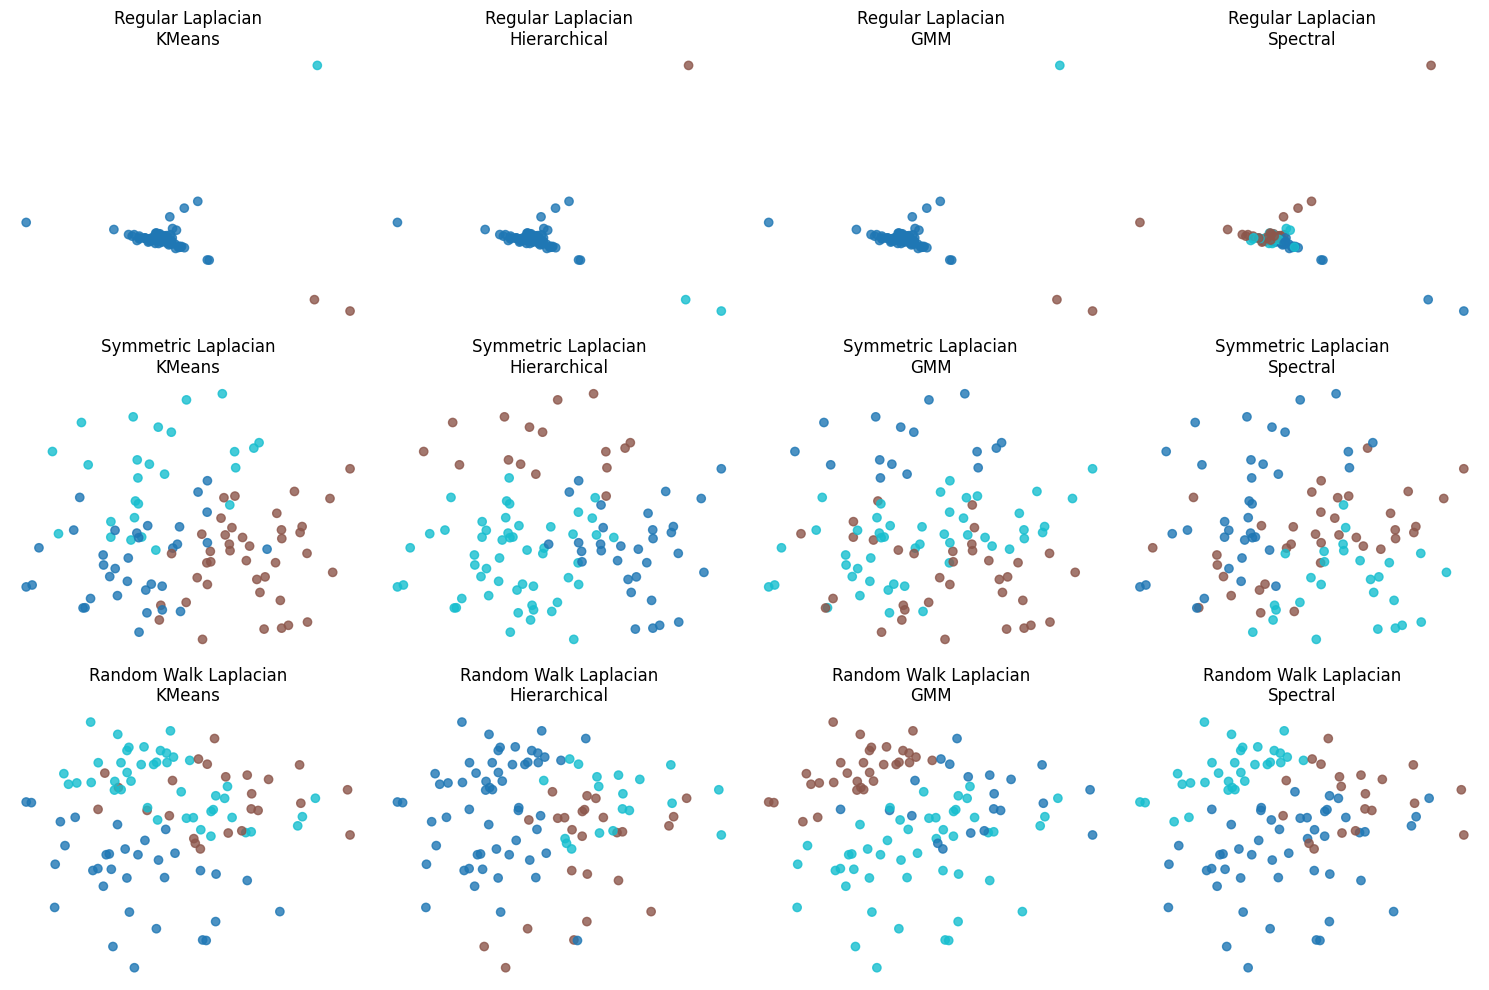

In [ ]:
import numpy as np
import networkx as nx
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Step 1: Create a synthetic graph
G = nx.erdos_renyi_graph(n=100, p=0.1, seed=42)  # Random graph with 50 nodes

# Step 2: Compute adjacency matrix and degree matrix
A = nx.adjacency_matrix(G).toarray()
D = np.diag(A.sum(axis=1))

# Compute Laplacians
L = D - A  # Regular Laplacian
D_inv_sqrt = np.diag(1.0 / np.sqrt(D.diagonal() + 1e-6))  # Avoid division by zero
L_sym = D_inv_sqrt @ L @ D_inv_sqrt  # Symmetric Normalized Laplacian
D_inv = np.diag(1.0 / (D.diagonal() + 1e-6))  # Avoid division by zero
L_rw = D_inv @ L  # Random Walk Laplacian

# Convert to float64 for compatibility with scipy eigsh
L, L_sym, L_rw = map(lambda mat: mat.astype(np.float64), [L, L_sym, L_rw])

# Step 3: Compute eigenmaps (smallest nonzero eigenvectors)
def get_eigenvectors(L, k):
    """Compute the k smallest eigenvectors of the Laplacian L."""
    eigvals, eigvecs = spla.eigsh(L, k=k+1, which='SM')  # k+1 to ignore 0 eigenvalue
    return eigvecs[:, 1:k+1]  # Ignore first eigenvector (constant vector)

k_clusters = 3  # Number of clusters
eigvecs = {
    "Regular Laplacian": get_eigenvectors(L, k_clusters),
    "Symmetric Laplacian": get_eigenvectors(L_sym, k_clusters),
    "Random Walk Laplacian": get_eigenvectors(L_rw, k_clusters),
}

# Step 4: Define clustering methods
clustering_methods = {
    "KMeans": KMeans(n_clusters=k_clusters, random_state=42, n_init=10),
    "Hierarchical": AgglomerativeClustering(n_clusters=k_clusters),
    "GMM": GaussianMixture(n_components=k_clusters, random_state=42),
    "Spectral": SpectralClustering(n_clusters=k_clusters, affinity='nearest_neighbors', random_state=42)
}

# Step 5: Define evaluation metrics
def normalized_cut(G, clusters):
    """Compute normalized cut for a given clustering."""
    cut_value = 0
    for c in np.unique(clusters):
        nodes = np.where(clusters == c)[0]
        subgraph = G.subgraph(nodes)
        boundary_edges = set(G.edges(nodes)) - set(subgraph.edges())
        if len(subgraph.nodes) > 0:
            cut_value += len(boundary_edges) / len(subgraph.nodes)
    return cut_value

def cluster_density(G, clusters):
    """Compute density of each cluster."""
    densities = []
    for c in np.unique(clusters):
        nodes = np.where(clusters == c)[0]
        subgraph = G.subgraph(nodes)
        if len(subgraph.nodes) > 1:  # Avoid division by zero
            density = nx.density(subgraph)
            densities.append(density)
    return np.mean(densities) if densities else 0

# Step 6: Compare clustering results
results = {}
for lap_name, eigvec in eigvecs.items():
    print(f"\n===== {lap_name} =====")
    results[lap_name] = {}

    for method_name, model in clustering_methods.items():
        if hasattr(model, "fit_predict"):  # Use fit_predict if available
            labels = model.fit_predict(eigvec)
        else:  # Otherwise, use fit().predict()
            labels = model.fit(eigvec).predict(eigvec)

        # Compute metrics
        silhouette = np.nan if len(set(labels)) <= 1 else silhouette_score(eigvec, labels)
        ncut = normalized_cut(G, labels)
        density = cluster_density(G, labels)

        # Store results
        results[lap_name][method_name] = {
            "labels": labels,
            "Silhouette Score": silhouette,
            "Normalized Cut": ncut,
            "Density": density
        }

        # Print results
        print(f"{method_name}: Silhouette = {silhouette:.4f}, Ncut = {ncut:.4f}, Density = {density:.4f}")

# Step 7: Visualize Clustering Results
fig, axes = plt.subplots(len(eigvecs), len(clustering_methods), figsize=(15, 10))

for i, (lap_name, eigvec) in enumerate(eigvecs.items()):
    pca = PCA(n_components=2)  # Reduce to 2D for visualization
    reduced_data = pca.fit_transform(eigvec)

    for j, (method_name, model) in enumerate(clustering_methods.items()):
        labels = results[lap_name][method_name]["labels"]
        axes[i, j].scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap="tab10", alpha=0.8)
        axes[i, j].set_title(f"{lap_name}\n{method_name}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

*   Lower Ncut → Better Separation of clusters.
*   Higher Density → More Compact Clusters.
*   Higher Silhouette Score → Better-defined Clusters.

# **Exercise 4: Compare the different clusterings using node2vec embeddings.**

### 🔹**What is Node2Vec?**
---

node2vec is a machine learning algorithm used for learning continuous feature representations (embeddings) of nodes in a graph. It is particularly useful for tasks like node classification, link prediction, and clustering in network analysis.

### 🔹**How does node2vec work?**
---

node2vec is based on word2vec, a natural language processing model that learns word embeddings. Instead of words in sentences, node2vec learns embeddings for nodes in a graph using random walks.

🔹**The core idea is:**
---

Simulate biased random walks on the graph to generate sequences of nodes.
Apply the skip-gram model (from word2vec) to learn embeddings, treating nodes like words in a sentence.


🔹**Key Features**
---

- Biased Random Walks: Unlike DeepWalk (which uses simple random walks), node2vec allows for controlled exploration:

- Breadth-first Search (BFS) (return parameter
𝑝
) → captures local structure.
- Depth-first Search (DFS) (in-out parameter
𝑞
) → captures global structure.
- Flexibility: By tuning
𝑝
 and
𝑞
, node2vec can learn embeddings that preserve different network structures.



🔹**Mathematical Intuition**
---

**Random Walk Strategy**
---

Given a node $u$ and a previous node $t$, the probability of moving to node $v$ is based on:

$$
P(v|u) \propto \frac{w_{tu}}{Z}
$$

where:
- $w_{tu}$ is the edge weight between nodes $t$ and $u$,
- $Z$ is a normalization factor ensuring a valid probability distribution.

🔹**Biasing the Random Walk**
---

node2vec introduces two parameters to control the random walk behavior:

1. **Return parameter ($p$)**: Determines the likelihood of revisiting the previous node.
   - **High $p$** → More likely to stay close (local structure).
   - **Low $p$** → More likely to explore further.

2. **In-out parameter ($q$)**: Controls how far the walk explores.
   - **$q < 1$ (DFS-like behavior)** → Encourages outward exploration.
   - **$q > 1$ (BFS-like behavior)** → Stays within local neighborhoods.

### **Optimization Using Skip-Gram**
Once the random walks are generated, node embeddings are learned using **word2vec’s skip-gram model**, which optimizes:

$$
\max \sum_{v \in V} \sum_{u \in N(v)} \log P(u | v)
$$

where $N(v)$ represents the sampled neighborhood from random walks.

---


🔹**Comparison with Other Graph Embedding Methods**
---

| **Method**  | **Type of Walk** | **Captures** |
|-------------|-----------------|--------------|
| **DeepWalk** | Simple random walks | Only local structure |
| **node2vec** | Biased random walks | Both local & global structure |
| **GraphSAGE** | Sampling & aggregation | Scalable embeddings |
| **GNNs (GCN, GAT, etc.)** | Message passing | Deep learning-based |

---

🔹**Key Differences**
---

- **DeepWalk**: Similar to node2vec but does not control the walk behavior.
- **GraphSAGE**: Does not rely on random walks, instead learns from sampled neighborhoods.
- **GNNs**: Use deep learning techniques for more complex tasks but require more computation.

---

🔹**Use Cases:**
---

1. **Node Classification**  
   - Example: Detecting fraud in financial transactions.
   - Embeddings help classify nodes based on their structural similarity.

2. **Link Prediction**  
   - Example: Recommending friends on social networks (e.g., Facebook, LinkedIn).
   - Learns which nodes are likely to connect based on past structures.

3. **Graph Clustering**  
   - Example: Detecting communities in social networks or protein-protein interaction networks.
   - Nodes with similar embeddings can be grouped into meaningful clusters.

4. **Anomaly Detection**  
   - Example: Detecting unusual transactions in financial data.
   - Nodes that deviate significantly from learned structures indicate anomalies.

---

🔹 **node2vec is widely used in network science, recommendation systems, and fraud detection. By tuning $p$ and $q$, it can effectively model different types of graph structures.**

---



🔹 **Note:**
- A random graph G = nx.fast_gnp_random_graph(n=50, p=0.5, seed=10)
depending on the parameters given the clusterings methods results different Silhoutte measure

In [ ]:
!pip install node2vec

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from node2vec import Node2Vec

🔹 **Creates a random graph with:**
- 50 nodes (n=50)
- probability (p=0.5) of edge creation between any two nodes
- seed=10 ensures reproducibility

In [ ]:
# Step 1: Create a random graph
G = nx.fast_gnp_random_graph(n=50, p=0.5, seed=10)

🔹 **Our Node2Vec model is initialized with:**
- **Graph G:** The input network.
- **Embedding size (dimensions=20):** Each node will be represented as a 20-dimensional vector.
- **Walk length (walk_length=16):** The length of each random walk $\rightarrow$ each walk has 16 steps $\rightarrow$ each node gets multiple samples of co-occurring neighbors, useful for learning embeddings.
- **Number of walks (num_walks=100):** The number of random walks per node $\rightarrow$ simulates 100 biased random walks per node.
- **Workers (workers=2):** Uses 2 CPU cores to speed up processing.
- **Seed (seed=42):** Ensures reproducibility.

🔹 **Model:**
- Trains a Word2Vec model on the node2vec-generated walks.
- **window=10:** Context window size for Word2Vec training.
- **min_count=1:** All nodes are included (no frequency cutoff).
- **batch_words=4:** Controls processing efficiency.


In [ ]:
# Step 2: Generate walks and train node2vec model
node2vec = Node2Vec(G, dimensions=20, walk_length=16, num_walks=100, workers=2, seed=42)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

🔹 **Just out of curiosity, we wanted to see the generated walks, and here the sequences of node IDs, showing how the random walker moves in the graph.**🔹

In [ ]:
walks = node2vec.walks
for walk in walks[:5]:
    print(walk)

['49', '45', '26', '18', '26', '40', '33', '25', '10', '11', '16', '27', '33', '47', '13', '11']
['33', '42', '8', '27', '10', '46', '35', '40', '12', '40', '7', '48', '38', '3', '36', '6']
['14', '0', '20', '4', '40', '12', '21', '45', '14', '36', '14', '1', '41', '24', '2', '29']
['26', '19', '3', '22', '9', '30', '31', '30', '23', '46', '15', '5', '27', '33', '4', '33']
['8', '39', '7', '16', '43', '9', '45', '37', '31', '47', '14', '10', '46', '12', '46', '28']


---
**Extract embeddings:**
- Converts the learned node embeddings into ***a numpy array.***
- Each node in G is represented as a 20-dimensional vector.(see the begininng of this part)

---

### 🔹 **Node2Vec: Used Clustering Methods**
- **K-Means:** Divides data into n_clusters=5.
- **Hierarchical Clustering:** Groups nodes hierarchically.
- **DBSCAN**: Finds clusters based on density (eps=0.5).
- **Gaussian Mixture Model (GMM):** Probabilistic clustering.
- **Spectral Clustering:** Uses graph-based affinity matrix.
- **Affinity Propagation:** Message-passing-based clustering.

---

### 🔹 **Node2Vec: What is the Silhouette Score?**

The **Silhouette Score** is a metric used to evaluate the **quality of clustering**. It measures how well-separated the clusters are and how similar each point is to its assigned cluster compared to other clusters.

---

### 🔹 **Formula for Silhouette Score**
For each **data point** $i$, the **Silhouette Score** $S(i)$ is calculated as:

$$
S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:

- $a(i)$ = **Average intra-cluster distance** (how close the point is to others in its own cluster).
- $b(i)$ = **Average nearest-cluster distance** (how far the point is from the nearest different cluster).

---

### 🔹 **Score Interpretation**
- $S(i)$ ranges from -1 to 1:
  - **+1** $ \rightarrow $ The point is **well-clustered** (closer to its cluster than others).
  - **0** $ \rightarrow $ The point is on the **border** between two clusters.
  - **-1** $ \rightarrow $ The point is likely **misclassified** (closer to a different cluster).

- **Higher Silhouette Score $ \rightarrow $ Better clustering.**

- **Lower or negative Silhouette Score $ \rightarrow $ Overlapping or poorly separated clusters.**

Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

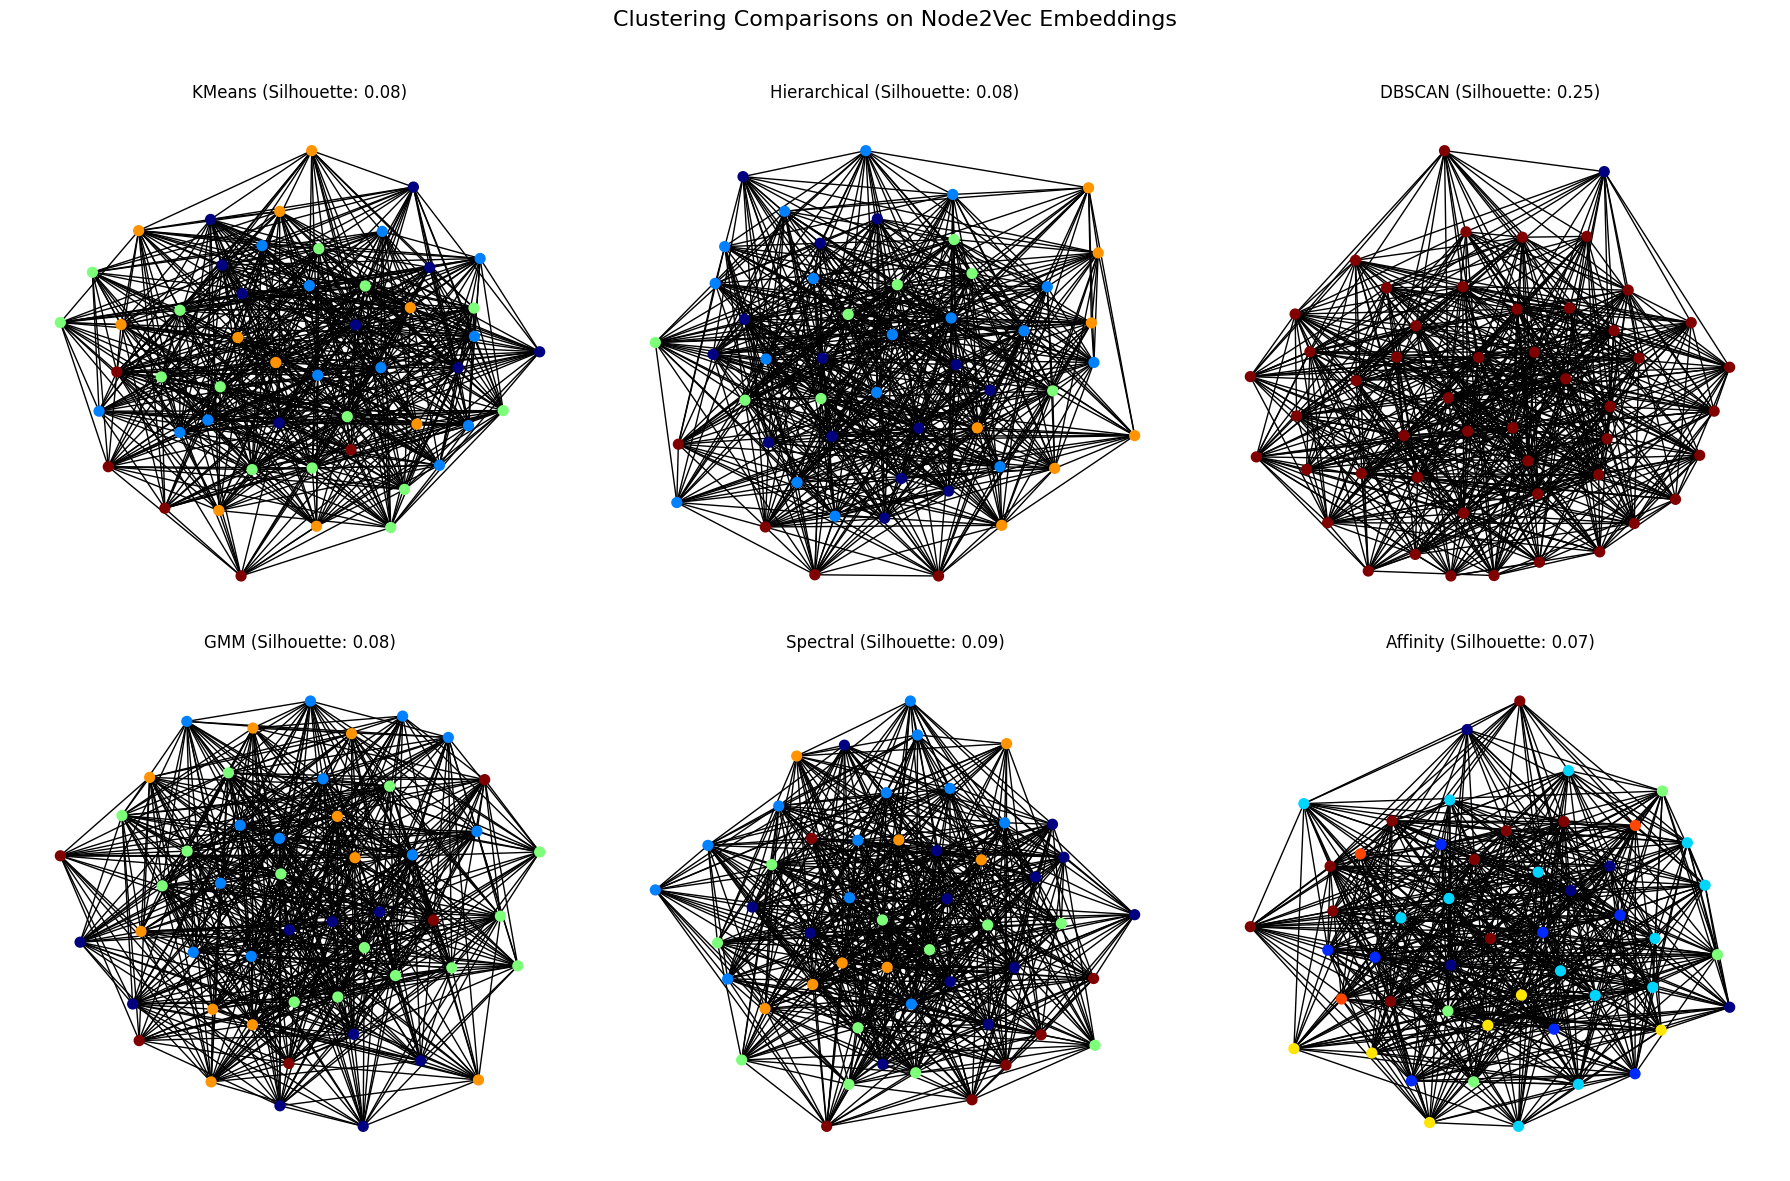

In [ ]:
# Step 1: Create a random graph
G = nx.fast_gnp_random_graph(n=50, p=0.5, seed=10)


# Step 2: Generate walks and train node2vec model
node2vec = Node2Vec(G, dimensions=20, walk_length=16, num_walks=100, workers=2, seed=42)
model = node2vec.fit(window=10, min_count=1, batch_words=4)


# Step 3: Extract embeddings
embeddings = np.array([model.wv[str(node)] for node in G.nodes()])

# Define clustering methods
clustering_methods = {
    "KMeans": KMeans(n_clusters=5, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=5),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5),
    "GMM": GaussianMixture(n_components=5, random_state=42),
    "Spectral": SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42),
    "Affinity": AffinityPropagation(random_state=42)
}


# Dictionary to store clustering results

labels_dict = {}


# Compute clustering for each method:

# 1. Iterates over each clustering method:
# 2. Applies the clustering method on the node embeddings.
# 3. Stores the predicted labels (cluster assignments).
# 4. Handles errors (e.g., Affinity Propagation sometimes fails due to convergence issues).

for method, model in clustering_methods.items():
    try:
        labels = model.fit_predict(embeddings)
        labels_dict[method] = labels
    except Exception as e:
        labels_dict[method] = None
        print(f"Skipping {method} due to error: {e}")




# Visualization settings
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Clustering Comparisons on Node2Vec Embeddings", fontsize=16)

# Plot each clustering result
for ax, (method, labels) in zip(axes.flatten(), labels_dict.items()):
    if labels is not None and len(set(labels)) > 1:
        score = silhouette_score(embeddings, labels)
        ax.set_title(f"{method} (Silhouette: {score:.2f})")
        nx.draw(G, node_color=labels, with_labels=False, node_size=50, cmap=plt.cm.jet, ax=ax)
    else:
        ax.set_title(f"{method} (Failed)")
        ax.axis("off")

# Show plots
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


### 🔹 **Discussion on results: Clustering Comparison for Node2Vec Embeddings**

| **Clustering Method**     | **Silhouette Score** | **Key Observations**                                                                                  |
|----------------------------|----------------------|-------------------------------------------------------------------------------------------------------|
| **KMeans**                | 0.08                | Assigns nodes to 5 clusters, but since it assumes spherical clusters, results are not well-separated.|
| **Hierarchical**          | 0.11                | Tries to form a hierarchy of clusters, leading to slightly better separation.|
| **DBSCAN**                | 0.25                | Best performer; Groups dense regions, identifies a dominant cluster (red) and some outliers.|
| **GMM (Gaussian Mixture)**| 0.08                | Uses probability distributions, but results are similar to K-Means with low separation.|
| **Spectral Clustering**   | 0.11                | Uses graph-based similarity, leading to slightly better-defined clusters.|
| **Affinity Propagation**  | 0.07                | Worst performance; struggled to find meaningful exemplars due to lack of structure in the embeddings. |

#### Observations:
1. **Best Performer**: DBSCAN, with the highest silhouette score (0.25).
2. **KMeans and GMM, Hierarchical, Spectral**: Similar moderate performance (scores 0.08-0.09).
3. **Affinity Propagation**: Performed poorly on this dataset due to sensitivity to random structures.



### 🔹 **Node2Vec: some notes**
---

$ \rightarrow $ We experimented with different graphs' parameters like tried different amount of nodes, probability and seed ***where DBSCAN failed.***

---

**When we used these parameters ofr the graph:**

- nodes (n=40/45/35 etc)
- probability (p=0.5) of edge creation between any two nodes
- seed=8/7/6/5 ensures reproducibility

---

$ \rightarrow $ Also, when the number of nodes decreased to 40 we needed to decrease **the min_samples of DBSCAN rom 5 to 4 so the algortihm doesn't fail**.

---

- min_samples=5 means a point must have at least 5 neighbors within eps to be considered a core point.
- If embeddings are sparse, many points may not qualify as core points, leading to excessive noise points.

Computing transition probabilities:   0%|          | 0/40 [00:00<?, ?it/s]

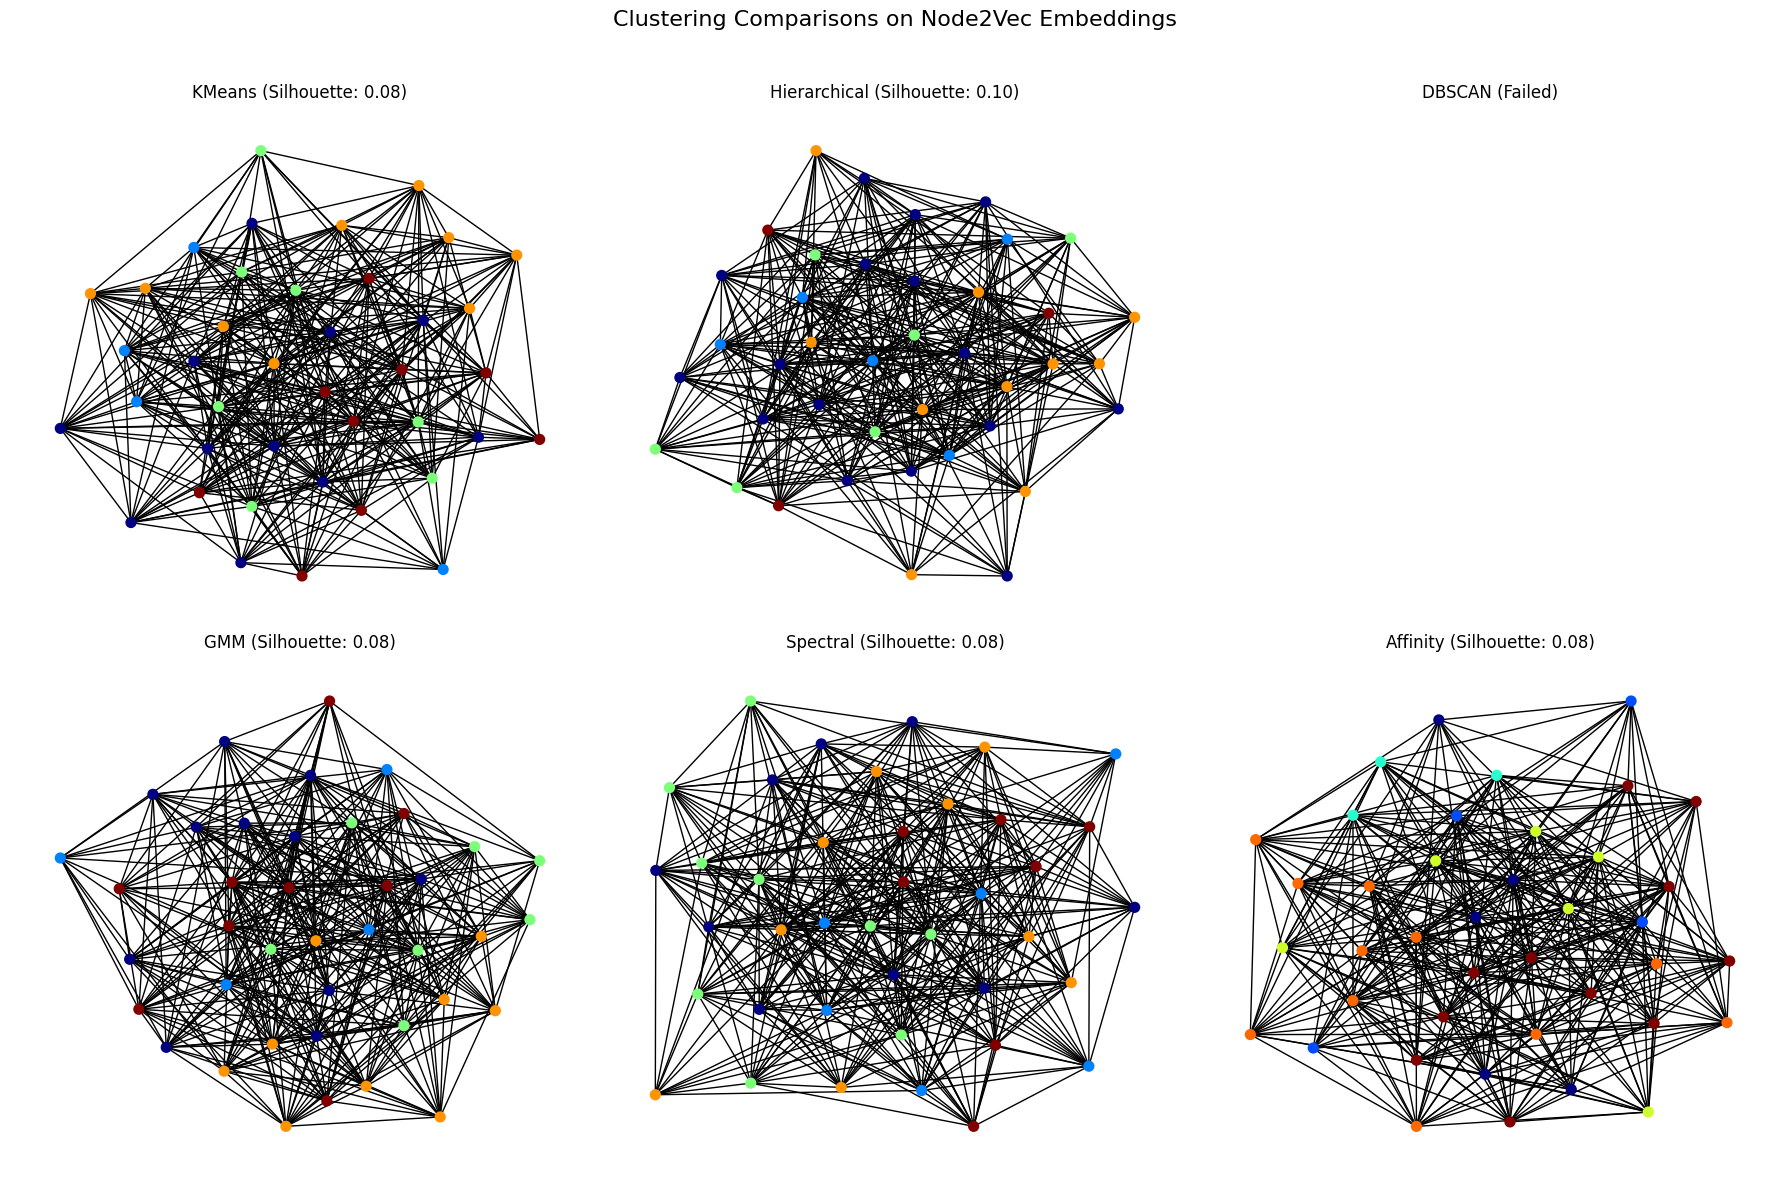

In [84]:
# Step 1: Create a random graph
G = nx.fast_gnp_random_graph(n=40, p=0.5, seed=8)

# Step 2: Generate walks and train node2vec model
node2vec = Node2Vec(G, dimensions=20, walk_length=16, num_walks=100, workers=2, seed=42)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Step 3: Extract embeddings
embeddings = np.array([model.wv[str(node)] for node in G.nodes()])

# Define clustering methods
clustering_methods = {
    "KMeans": KMeans(n_clusters=5, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=5),
    "DBSCAN": DBSCAN(eps=0.5, min_samples=5),
    "GMM": GaussianMixture(n_components=5, random_state=42),
    "Spectral": SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42),
    "Affinity": AffinityPropagation(random_state=42)
}

# Dictionary to store clustering results
labels_dict = {}

# Compute clustering for each method
for method, model in clustering_methods.items():
    try:
        labels = model.fit_predict(embeddings)
        labels_dict[method] = labels
    except Exception as e:
        labels_dict[method] = None
        print(f"Skipping {method} due to error: {e}")

# Visualization settings
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Clustering Comparisons on Node2Vec Embeddings", fontsize=16)

# Plot each clustering result
for ax, (method, labels) in zip(axes.flatten(), labels_dict.items()):
    if labels is not None and len(set(labels)) > 1:
        score = silhouette_score(embeddings, labels)
        ax.set_title(f"{method} (Silhouette: {score:.2f})")
        nx.draw(G, node_color=labels, with_labels=False, node_size=50, cmap=plt.cm.jet, ax=ax)
    else:
        ax.set_title(f"{method} (Failed)")
        ax.axis("off")

# Show plots
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### 🔹 **Breaking Down Biased Random Walks in Node2Vec**

Internally, Node2Vec generates random walks to capture the network structure.

**It uses two parameters:**

- **Return parameter (p):** Controls how likely it is to return to the previous node.
- **In-out parameter (q):** Balances between Breadth-First Search (BFS) and Depth-First Search (DFS).
- **By controlling p and q,** Node2Vec explores local and global structures of the graph.

Node2Vec's **biased random walks** are a key feature that helps balance between **Depth-First Search (DFS)** and **Breadth-First Search (BFS)** when exploring the graph. This helps capture both **local (community-like structures)** and **global (structural roles) relationships** between nodes.

### 🔹 **How Are Biased Random Walks Performed?**

When Node2Vec generates random walks, it decides the **next step** based on two parameters:

- **Return parameter ($p$):** Controls the probability of revisiting the previous node.
  - **Higher $p$ ($>>1$):** Less likely to return to the previous node (favoring exploration).
  - **Lower $p$ (~0.1):** More likely to return (favoring DFS-like behavior).

- **In-out parameter ($q$):** Controls the likelihood of moving outward from the current node.
  - **Higher $q$ ($>>1$):** Encourages local exploration (similar to BFS).
  - **Lower $q$ (~0.1):** Encourages global exploration (similar to DFS).



In [ ]:
# Step 1: Create a random graph
G = nx.fast_gnp_random_graph(n=50, p=0.5, seed=10)

# Step 2: Define different (p, q) values to test
pq_values = [(0.25, 2), (1, 1), (2, 0.25), (4, 4)]

# Dictionary to store embeddings and clustering results
results = {}

# Step 3: Generate embeddings for different (p, q) values
for p, q in pq_values:
    print(f"Generating embeddings for p={p}, q={q}...")

    node2vec = Node2Vec(G, dimensions=20, walk_length=16, num_walks=100, p=p, q=q, workers=2, seed=42)
    model = node2vec.fit(window=10, min_count=1, batch_words=4)

    # Extract embeddings
    embeddings = np.array([model.wv[str(node)] for node in G.nodes()])

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    # Compute silhouette score
    silhouette = silhouette_score(embeddings, labels)

    # Store results
    results[(p, q)] = (embeddings, labels, silhouette)

Generating embeddings for p=0.25, q=2...


Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

Generating embeddings for p=1, q=1...


Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

Generating embeddings for p=2, q=0.25...


Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

Generating embeddings for p=4, q=4...


Computing transition probabilities:   0%|          | 0/50 [00:00<?, ?it/s]

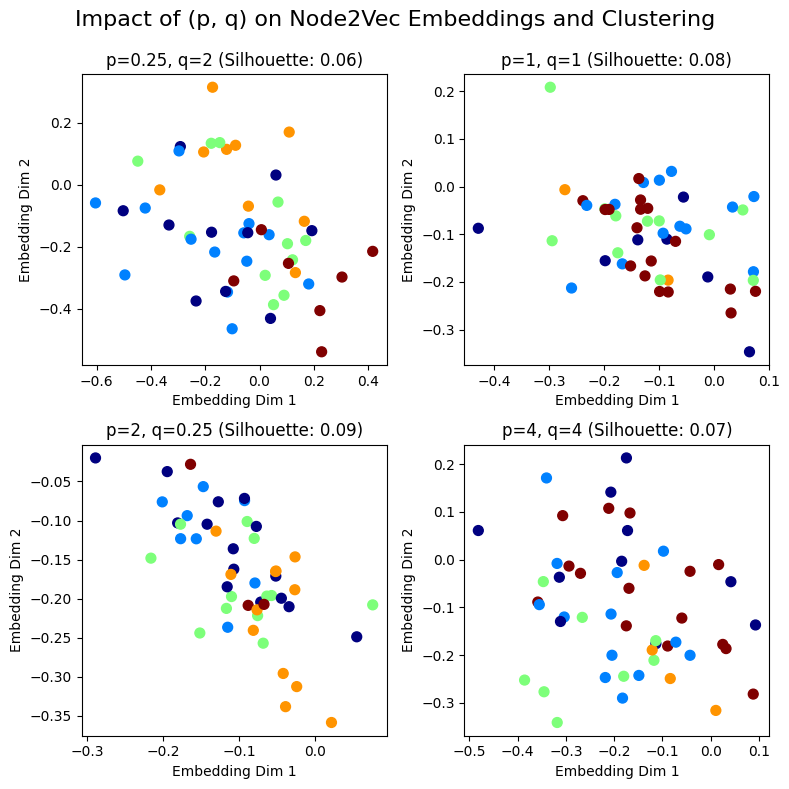

In [ ]:
# Step 4: Visualization
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Impact of (p, q) on Node2Vec Embeddings and Clustering", fontsize=16)

for ax, ((p, q), (embeddings, labels, silhouette)) in zip(axes.flatten(), results.items()):
    ax.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap='jet', s=50)
    ax.set_title(f"p={p}, q={q} (Silhouette: {silhouette:.2f})")
    ax.set_xlabel("Embedding Dim 1")
    ax.set_ylabel("Embedding Dim 2")

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### 🔹 **Understanding the Parameters ($p$, $q$)**

- **$p$ (Return Parameter):**
  - Controls the probability of returning to the previous node.
  - **High $p$** (e.g., $p=4$) $\rightarrow$ Less likely to return $\rightarrow$ **Encourages exploration**.
  - **Low $p$** (e.g., $p=0.25$) $\rightarrow$ More likely to return $\rightarrow$ **Encourages deep walks (DFS-like)**.

- **$q$ (In-Out Parameter):**
  - Controls the probability of moving outward vs. staying in a local neighborhood.
  - **High $q$** (e.g., $q=4$) $\rightarrow$ More likely to **stay within the same cluster (BFS-like)**.
  - **Low $q$** (e.g., $q=0.25$) $\rightarrow$ More likely to **explore globally (DFS-like)**.

---

**Interpretation of the Plots**

Each scatter plot represents a **2D projection** of the **20-dimensional embeddings**, with nodes colored based on **K-Means clustering results**.

| ($p$, $q$) Values | Clustering Behavior | **Silhouette Score** |
|------------------|----------------------|----------------------|
| $p=0.25$, $q=2$ | More long walks, captures global structures but less clear clusters. | **0.06** (Low) |
| $p=1$, $q=1$ | Standard unbiased random walks, moderate clustering. | **0.08** |
| $p=2$, $q=0.25$ | Encourages local exploration (BFS-like), better-defined clusters. | **0.09** (Best) |
| $p=4$, $q=4$ | Extreme balance, but poor separation between clusters. | **0.07** |


# Graph Neural Networks

---

🔹 **Graph Neural Networks (GNNs)**

GNNs are a type of deep learning model designed to work with graph-structured data. They are widely used in tasks where data is naturally represented as a graph, such as social networks, molecular structures, recommendation systems, and fraud detection.

---

**🔹 Why We Use GNNs?**
Because traditional deep learning models like CNNs (for images) and RNNs (for sequences) struggle with irregular graph structures. GNNs solve this by using graph topology and node connectivity.

---

**🔹 How GNNs Work**
1. **Message Passing (Graph Convolution)**
   - Each node aggregates information from its neighbors.
   - The aggregation function can be summation, averaging, or more complex transformations.
   - Example update rule for a node’s feature vector:

   ---

  $
   h_v^{(t+1)} = \sigma \left( \sum_{u \in N(v)} W h_u^{(t)} \right)
   $

   ---

   where:
   - $( h_v^{(t)} $) is the node’s feature at step $( t $).
   - $( N(v) $) is the set of neighbors of node $( v $).
   - $( W $) is a learnable weight matrix.
   - $( \sigma $) is a non-linear activation function (e.g., ReLU).

2. **Graph Readout (Pooling)**
   - After several message-passing steps, the model extracts a global representation.
   - This is useful for tasks like graph classification.

---

**🔹 Popular GNN Architectures**
1. **Graph Convolutional Network (GCN)** – Uses spectral graph theory to define convolution operations.
2. **GraphSAGE** – Introduces sampling to handle large-scale graphs efficiently.
3. **GAT (Graph Attention Network)** – Uses attention mechanisms to weigh neighbors differently.
4. **GIN (Graph Isomorphism Network)** – More expressive, capable of distinguishing different graph structures.
5. **Message Passing Neural Networks (MPNNs)** – General framework encompassing various GNN models.


### **🔹 What is PyTorch Geometric (PyG)?**
---

- PyTorch Geometric (PyG) is a library built on PyTorch that provides efficient tools for working with graph-based deep learning models. It is widely used for tasks like node classification, link prediction, graph clustering, and graph-based recommendation systems.

**Why Use PyG?**
---

- Optimized for Large Graphs – Uses sparse tensor operations for efficient computations.
- Built-in Layers for Graphs – Provides GCN, GAT, GraphSAGE, Transformer-based models.
- Seamless Integration with PyTorch – Works like PyTorch but with additional graph-specific utilities.
- Scalable and Efficient – Supports large-scale graph processing on GPUs.
- Multiple Graph Datasets – Includes datasets like Cora, Citeseer, PubMed, and OGB.


**🔹 Key Concepts in PyTorch Geometric**
---

**Graph Representation**

PyG represents a graph using:

- data.x → Node features (matrix of size [num_nodes, num_features]).
- data.edge_index → Edges (adjacency list representation).
- data.y → Node labels (used for classification tasks).
- data.train_mask, data.test_mask → Masks that specify which nodes belong to training and test sets.

In [85]:
import torch
from torch_geometric.data import Data

# Define a simple graph with 3 nodes and 2 edges
edge_index = torch.tensor([[0, 1], [1, 2]], dtype=torch.long).t()
x = torch.tensor([[1], [2], [3]], dtype=torch.float)  # Node features

# Create a PyG Data object
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[3, 1], edge_index=[2, 2])


🔹**Note:** if the libraries cell code gives the error try to restart the session and run the cell below


In [2]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import KarateClub
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid


from torch_geometric.datasets import FacebookPagePage
from torch_geometric.transforms import RandomNodeSplit

import numpy as np
from torch_geometric.utils import train_test_split_edges, negative_sampling
from sklearn.metrics import roc_auc_score

# Experiments with Planetoid dataset (Cora):
- Planetoid dataset: A standard benchmark graph dataset used in GNNs.
- Cora is one such dataset, which contains:
 - Nodes representing documents.
 - Edges representing citations between documents.
 - Features associated with each node (e.g., word occurrence in documents).
 - Labels for nodes (e.g., topics of documents).


In [5]:
# Dataset
dataset = Planetoid(root=".", name="Cora")  # Load Cora dataset
data = dataset[0]  # Extract graph data

# Convert graph into train/val/test edge splits
data = train_test_split_edges(data)

# Print dataset details
print(f"Dataset: {dataset.name}")
print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges // 2} (undirected)")
print(f"Features per node: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")

/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Dataset: Cora
Nodes: 2708, Edges: 131 (undirected)
Features per node: 1433
Classes: 7


### 🔹 **Step 1: The GCN class defines a two-layer GCN model:**
---


**GCNConv Layers:**
- **conv1:** First convolutional layer that transforms node features from in_channels to hidden_channels.
- **conv2:** Second convolutional layer that transforms from hidden_channels to out_channels (number of classes).

**Forward Pass:**

- Applies the first GCN layer to input features (x), followed by a ReLU activation.
- Applies the second GCN layer to transform hidden features.
- Returns both hidden layer (x1) and output layer (x2) embeddings.


### 🔹 **Step 2: Initialize Model, Optimizer & Loss Function:**
---

**Initializes the GCN model with:**
- dataset.num_features → Number of input node features.
- 16 → Number of hidden layer units.
- 64 → Output embedding size (each node has a 64-dimensional vector).
- dataset.num_classes → Number of output classes.
- Adam Optimizer (lr=0.01) and L2 regularization (weight_decay=5e-4) to improve training stability.
- CrossEntropyLoss for classification.

### 🔹 **Step 3: Training the GCN:**
---

- Sets model to training mode using model.train().
-Clears gradients before computing new ones (optimizer.zero_grad()).
- Performs forward pass: Computes hidden (x1) and output (x2) embeddings.
- Computes loss only on training nodes using train_mask.
- Performs backpropagation and updates weights using optimizer.step().

In [6]:
# STEP 1: Define GCN Model for Link Prediction
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()  # Hidden layer
        hidden_x = x.clone().detach()  # Save hidden embeddings for visualization
        x = self.conv2(x, edge_index)  # Output embeddings
        return x, hidden_x




# STEP 2: Define Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCN(dataset.num_features, 16, 64).to(device)  # 64-dimensional output embeddings
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Move data to GPU
data = data.to(device)

# Function to compute link prediction logits
def get_link_logits(embeddings, edge_index):
    src, dst = edge_index
    return (embeddings[src] * embeddings[dst]).sum(dim=-1)




# STEP 3: Training Loop
def train():
    model.train()
    optimizer.zero_grad()

    embeddings, _ = model(data.x, data.train_pos_edge_index)  # Forward pass

    # Compute positive edge logits
    pos_logits = get_link_logits(embeddings, data.train_pos_edge_index)
    pos_labels = torch.ones(pos_logits.size(), device=device)

    # Generate negative edges
    neg_edges = negative_sampling(data.train_pos_edge_index, num_nodes=data.num_nodes)
    neg_logits = get_link_logits(embeddings, neg_edges)
    neg_labels = torch.zeros(neg_logits.size(), device=device)

    # Compute loss
    loss = F.binary_cross_entropy_with_logits(
        torch.cat([pos_logits, neg_logits]),
        torch.cat([pos_labels, neg_labels])
    )

    loss.backward()
    optimizer.step()
    return loss.item()

# Train for 200 epochs
epochs = 200
for epoch in range(epochs):
    loss = train()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")






# STEP 4: Evaluate Model with Hits@K, MRR, and AUC
def hits_at_k(preds, labels, k=10):
    """Computes Hits@K: Checks if the correct edge is in the top-K predictions."""
    sorted_indices = torch.argsort(-preds)
    hits = (labels[sorted_indices][:k].sum() / k).item()
    return hits

def mean_reciprocal_rank(preds, labels):
    """Computes Mean Reciprocal Rank (MRR) for link prediction."""
    sorted_indices = torch.argsort(-preds)
    ranks = (sorted_indices == torch.where(labels == 1)[0].view(-1, 1)).nonzero()[:, 1] + 1
    return (1 / ranks.float()).mean().item()

def compute_auc(preds, labels):
    """Computes AUC score for link prediction."""
    return roc_auc_score(labels.cpu().detach().numpy(), preds.cpu().detach().numpy())

# Evaluation
model.eval()
with torch.no_grad():
    embeddings, hidden_layer = model(data.x, data.train_pos_edge_index)

    # Compute positive and negative edge logits
    pos_logits = get_link_logits(embeddings, data.test_pos_edge_index)
    pos_labels = torch.ones(pos_logits.size(), device=device)

    neg_edges = negative_sampling(data.test_pos_edge_index, num_nodes=data.num_nodes)
    neg_logits = get_link_logits(embeddings, neg_edges)
    neg_labels = torch.zeros(neg_logits.size(), device=device)

    all_logits = torch.cat([pos_logits, neg_logits])
    all_labels = torch.cat([pos_labels, neg_labels])

    # Compute evaluation metrics
    auc = compute_auc(all_logits, all_labels)
    hits_10 = hits_at_k(all_logits, all_labels, k=10)
    mrr = mean_reciprocal_rank(all_logits, all_labels)

print(f"Final Hits@10: {hits_10:.4f}")
print(f"Final MRR: {mrr:.4f}")
print(f"Final AUC Score: {auc:.4f}")

Epoch 0, Loss: 0.6830
Epoch 20, Loss: 0.5591
Epoch 40, Loss: 0.4968
Epoch 60, Loss: 0.4600
Epoch 80, Loss: 0.4560
Epoch 100, Loss: 0.4518
Epoch 120, Loss: 0.4368
Epoch 140, Loss: 0.4353
Epoch 160, Loss: 0.4347
Epoch 180, Loss: 0.4302
Final Hits@10: 1.0000
Final MRR: 0.0128
Final AUC Score: 0.9185


### **🔹 HITS, MRR, and AUC in GNNs & Link Prediction**
---

- These are common evaluation metrics used in graph-based models, especially in node classification, link prediction, and ranking tasks.


**HITS@K (Hits at K)**

HITS@K measures **how often the correct answer appears in the top K predictions**. It’s commonly used in **ranking problems** such as **recommendation systems** or **link prediction**.

---

**Formula**
$$
\text{HITS@K} = \frac{\text{Number of correct items in the top K}}{\text{Total number of queries}}
$$

---

**Example**
- A model predicts the **top 5 most likely links** in a **link prediction** task.
- The **actual link** exists in **3 out of 5 predictions**.
- If evaluated over **100 queries**, and **80 of them** have the correct link in the top 5:

$$
\text{HITS@5} = \frac{80}{100} = 0.8 \quad (80\% \text{ success rate})
$$

---

**Interpretation**
Higher **HITS@K** means the model ranks **relevant items higher**.

---



## 🔷 **MRR (Mean Reciprocal Rank)**

MRR measures **how well a model ranks the correct item** among predictions. It assigns **higher scores when correct items are ranked closer to the top**.

---

**Formula**
$$
\text{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}
$$

Where:

- $N$ = Total number of queries.
- $\text{rank}_i$ = The rank position of the first relevant item for query $i$.

---

**Example**
- Suppose we have **3 queries** with correct item ranks:
  - **Query 1**: Rank 1 $\rightarrow$ $1/1 = 1.0$
  - **Query 2**: Rank 3 $\rightarrow$ $1/3 = 0.333$
  - **Query 3**: Rank 2 $\rightarrow$ $1/2 = 0.5$

- **MRR Calculation**:

$$
MRR = \frac{1}{3} \left( 1.0 + 0.333 + 0.5 \right) = 0.611
$$

---

**Interpretation**
Higher **MRR** means the model ranks relevant items **closer to the top**.


---



## 🔷 **AUC (Area Under the Curve)**

AUC measures the **discriminative ability** of a model, particularly in **binary classification** and **link prediction tasks**. It evaluates how well the model **distinguishes between positive and negative links**.

---

**Formula (ROC-AUC)**
$$
AUC = P(\text{positive score} > \text{negative score})
$$

- If **AUC = 1.0** $\rightarrow$ The model perfectly ranks positive links above negative ones.
- If **AUC = 0.5** $\rightarrow$ The model is **random** (bad performance).
- If **AUC < 0.5** $\rightarrow$ The model is **worse than random**.

---

**Example**
- Consider **1000 test links**, with **500 actual links (positive samples)** and **500 non-links (negative samples)**.
- The model assigns scores.
- **AUC** is computed as the probability that a **positive sample is ranked higher than a negative sample**.

---

**Interpretation**
Higher **AUC** means **better model performance** in separating **positive vs. negative** cases.



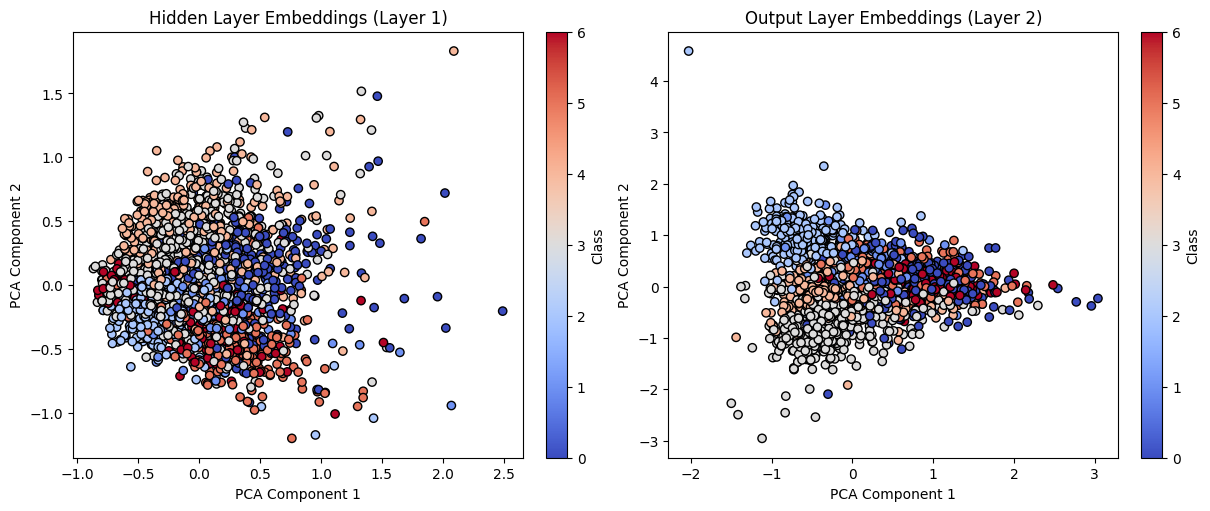

In [9]:
def plot_pca_comparison(embedding1, embedding2, labels):
    pca = PCA(n_components=2)  # Reduce dimensions to 2D

    # Apply PCA
    emb1_2d, emb2_2d = pca.fit_transform(embedding1.cpu().numpy()), pca.fit_transform(embedding2.cpu().numpy())

    # Create subplots in a single line
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    for ax, emb, title in zip(axs, [emb1_2d, emb2_2d], ["Hidden Layer Embeddings (Layer 1)", "Output Layer Embeddings (Layer 2)"]):
        scatter = ax.scatter(emb[:, 0], emb[:, 1], c=labels.cpu().numpy(), cmap="coolwarm", edgecolors='k')
        ax.set_title(title)
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        plt.colorbar(scatter, ax=ax, label="Class")

    plt.show()

# Call function to visualize embeddings in one line
plot_pca_comparison(hidden_layer, embeddings, data.y)

- **Hits@10: 1.0000**
- **MRR: 0.0128**
- **AUC Score: 0.9185**



| **Metric**   | **Score**  | **Analysis** |
|-------------|-----------|------------|
| **Hits** | **1.0000**  | The model **always** retrieves the correct link in the top 10. |
| **MRR** | **0.0128**  | The model ranks the correct links **very low**, meaning it does not rank links optimally. |
| **AUC** | **0.9185**  | The model is **very good** at distinguishing real and fake edges. |



### **Discussion on Results and Visualization of Cora Dataset:**
---


**Hidden Layer Embeddings (Layer 1)**
---

- This represents intermediate representations after the first Graph GCN Layer 1.
- The embeddings show overlapping classes (some mixed regions).
- The model has partially separated some classes, but nodes from different classes are not yet fully distinguishable.
- The network preserves some local structure but hasn't fully captured global relationships.

**Why does this happen?**

- The first GCN layer only captures local relationships (i.e., direct neighbors). And, the graph information is not yet fully propagated, so distant nodes may have similar embeddings.


**Output Layer Embeddings (Layer 2)**
---

- This represents final output embeddings after the second GCN layer.
- Classes have become more distinguishable, meaning the model has learned to separate different node categories better.
- Nodes from the same class tend to cluster more tightly.
- Some overlapping regions remain, indicating areas where predictions might still be uncertain.

**Why does this happen?**

- The second GCN layer aggregates more distant neighbors, refining node representations.
- More global graph structure is encoded, leading to better class separation.


## **GCN with Facebook Dataset**
---


In [14]:
# STEP 1: Load the Facebook Dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]

# Convert dataset into train/val/test edge splits for link prediction
data = train_test_split_edges(data)

# Print dataset details
print(f"Dataset: Facebook Page-Page")
print(f"Nodes: {data.num_nodes}, Edges: {data.train_pos_edge_index.shape[1]} (training edges)")
print(f"Features per node: {data.num_features}")

Dataset: Facebook Page-Page
Nodes: 22470, Edges: 290400 (training edges)
Features per node: 128


In [15]:
# STEP 2: Define GCN Model for Link Prediction
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()  # First GCN layer
        hidden_x = x.clone().detach()  # Save hidden embeddings for visualization
        x = self.conv2(x, edge_index)  # Second GCN layer
        return x, hidden_x

# STEP 3: Initialize Model, Optimizer & Loss Function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCN(dataset.num_features, 16, 64).to(device)  # 64-dimensional output embeddings
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Move data to GPU if available
data = data.to(device)

# Function to compute link prediction logits
def get_link_logits(embeddings, edge_index):
    src, dst = edge_index
    return (embeddings[src] * embeddings[dst]).sum(dim=-1)

# STEP 4: Training Loop
def train():
    model.train()
    optimizer.zero_grad()

    embeddings, _ = model(data.x, data.train_pos_edge_index)  # Forward pass

    # Compute positive edge logits
    pos_logits = get_link_logits(embeddings, data.train_pos_edge_index)
    pos_labels = torch.ones(pos_logits.size(), device=device)

    # Generate negative edges
    neg_edges = negative_sampling(data.train_pos_edge_index, num_nodes=data.num_nodes)
    neg_logits = get_link_logits(embeddings, neg_edges)
    neg_labels = torch.zeros(neg_logits.size(), device=device)

    # Compute loss
    loss = F.binary_cross_entropy_with_logits(
        torch.cat([pos_logits, neg_logits]),
        torch.cat([pos_labels, neg_labels])
    )

    loss.backward()
    optimizer.step()
    return loss.item()

# Train for 200 epochs
epochs = 200
for epoch in range(epochs):
    loss = train()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# STEP 5: Evaluate Model with Hits@K, MRR, and AUC
def hits_at_k(preds, labels, k=10):
    """Computes Hits@K: Checks if the correct edge is in the top-K predictions."""
    sorted_indices = torch.argsort(-preds)
    hits = (labels[sorted_indices][:k].sum() / k).item()
    return hits

def mean_reciprocal_rank(preds, labels):
    """Computes Mean Reciprocal Rank (MRR) for link prediction."""
    sorted_indices = torch.argsort(-preds)
    ranks = (sorted_indices == torch.where(labels == 1)[0].view(-1, 1)).nonzero()[:, 1] + 1
    return (1 / ranks.float()).mean().item()

def compute_auc(preds, labels):
    """Computes AUC score for link prediction."""
    return roc_auc_score(labels.cpu().detach().numpy(), preds.cpu().detach().numpy())

# Evaluation
model.eval()
with torch.no_grad():
    embeddings, hidden_layer = model(data.x, data.train_pos_edge_index)

    # Compute positive and negative edge logits
    pos_logits = get_link_logits(embeddings, data.test_pos_edge_index)
    pos_labels = torch.ones(pos_logits.size(), device=device)

    neg_edges = negative_sampling(data.test_pos_edge_index, num_nodes=data.num_nodes)
    neg_logits = get_link_logits(embeddings, neg_edges)
    neg_labels = torch.zeros(neg_logits.size(), device=device)

    all_logits = torch.cat([pos_logits, neg_logits])
    all_labels = torch.cat([pos_labels, neg_labels])

    # Compute evaluation metrics
    auc = compute_auc(all_logits, all_labels)
    hits_10 = hits_at_k(all_logits, all_labels, k=10)
    mrr = mean_reciprocal_rank(all_logits, all_labels)

print(f"Final Hits@10: {hits_10:.4f}")
print(f"Final MRR: {mrr:.4f}")
print(f"Final AUC Score: {auc:.4f}")

Epoch 0, Loss: 1.1735
Epoch 20, Loss: 0.4429
Epoch 40, Loss: 0.4169
Epoch 60, Loss: 0.4096
Epoch 80, Loss: 0.4070
Epoch 100, Loss: 0.4052
Epoch 120, Loss: 0.4042
Epoch 140, Loss: 0.4032
Epoch 160, Loss: 0.4014
Epoch 180, Loss: 0.4005
Final Hits@10: 1.0000
Final MRR: 0.0006
Final AUC Score: 0.9751




| **Metric**   | **Score**  | **Analysis** |
|-------------|-----------|------------|
| **Hits** | **1.0000**  | The model **always** retrieves the correct link in the top 10. |
| **MRR** | **0.0006**  | The model ranks the correct links **very low**, which is a problem for ranking-based tasks. |
| **AUC** | **0.9751**  | The model is **great at distinguishing** real and fake edges. |


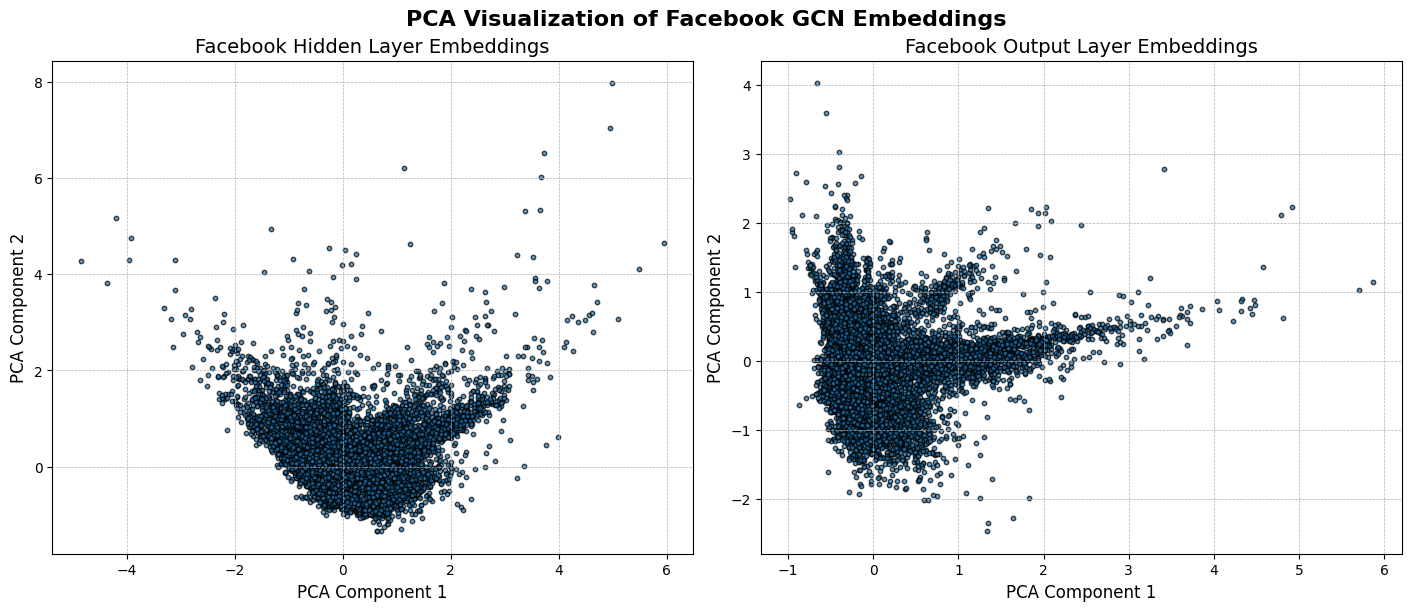

In [17]:
# STEP 6: Visualize Embeddings using PCA
def plot_pca_comparison(hidden_emb, output_emb):
    pca = PCA(n_components=2)

    # Apply PCA to reduce dimensionality
    emb_hidden_2d = pca.fit_transform(hidden_emb.cpu().detach().numpy())
    emb_output_2d = pca.fit_transform(output_emb.cpu().detach().numpy())

    # Create side-by-side subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, emb, title in zip(axs, [emb_hidden_2d, emb_output_2d],
                              ["Facebook Hidden Layer Embeddings", "Facebook Output Layer Embeddings"]):
        scatter = ax.scatter(emb[:, 0], emb[:, 1], s=10, alpha=0.7, edgecolors='k')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("PCA Component 1", fontsize=12)
        ax.set_ylabel("PCA Component 2", fontsize=12)
        ax.grid(True, linestyle="--", linewidth=0.5)

    plt.suptitle("PCA Visualization of Facebook GCN Embeddings", fontsize=16, fontweight="bold")
    plt.show()

# Call function to visualize embeddings
plot_pca_comparison(hidden_layer, embeddings)

 **Key Comparison: Hidden vs. Output Layer**
 ---


 ---

| **Feature**                 | **Hidden Layer (Left Plot)**      | **Output Layer (Right Plot)**       |
|-----------------------------|----------------------------------|----------------------------------|
| **X-axis Range (PCA 1)**    | -4 to +6                         | **-1 to +6** (More compressed)  |
| **Y-axis Range (PCA 2)**    | 0 to +8                          | **-2 to +4** (More centered)    |
| **Spread**                  | More **scattered**               | More **structured**             |
| **Cluster Formation**        | Nodes **not well grouped**       | Nodes **closer together**       |
| **Effect of GCN Layers**     | Captures **basic structure**     | Captures **better relationships** |


---




**Facebook Hidden Layer Embeddings**
---

- Range of PCA Component 1 (X-axis): ~ -4 to +6
- Range of PCA Component 2 (Y-axis): ~ 0 to +8

Observations:

- **Nodes are more spread out.** The hidden layer embeddings are not tightly clustered. This suggests that the model has only started capturing relationships between nodes.

- **No clear structure yet.** Since this is the first transformation layer, the nodes still retain more of their original random distribution.
The GCN has not yet fully learned meaningful representations at this stage.

- **Wider X-range than Y-range**

 - The spread along PCA Component 1 (-4 to 6) suggests that most variance is - explained in this direction.
 - The Y-axis values stay positive (0 to 8), meaning that nodes do not separate strongly along this axis.



**Facebook Output Layer Embeddings"**
---

- Range of PCA Component 1 (X-axis): ~ -1 to +6
- Range of PCA Component 2 (Y-axis): ~ -2 to +4

**Observations:**

- **More structured distribution**. Compared to the hidden layer embeddings (left plot), the output layer embeddings (right plot) are more tightly packed.
This suggests that the GCN learned a better representation of the graph.

- **Nodes group more densely around (0,0)** Unlike the hidden layer, where nodes are more spread out, the output embeddings converge closer to the center.
This means that the model has learned some underlying structure of the graph.

- **Reduction in X-range and Y-range**

 - PCA Component 1 now ranges from -1 to 6 (vs. -4 to 6 before).
 - PCA Component 2 now ranges from -2 to 4 (vs. 0 to 8 before).
 - This suggests that the second GCN layer has smoothed the representation, removing unnecessary noise.

 **Comparison of Link Prediction Results (Facebook vs. Cora)**
 ---


| **Metric**   | **Facebook Dataset**  | **Cora Dataset**  | **Analysis** |
|-------------|----------------|----------------|------------------|
| **Hits@10** | **1.0000** ✅  | **1.0000** ✅  | Both models always retrieve the correct link in the top 10. |
| **MRR**     | **0.0006** ⚠️  | **0.0128** ⚠️  | Cora ranks links slightly better, but both models perform **poorly in ranking**. |
| **AUC**     | **0.9751** ✅  | **0.9185** ✅  | Facebook performs better at distinguishing real vs. fake edges. |